# Exploratory Data Analysis (EDA)

## Table of Contents
1. Dataset Overview
2. Handling Missing Values
3. Feature Distributions & Possible Biases
4. Correlations & Multicollinearity
5. Causal Discovery
    * First DAG
    * Check for Identification
    * Improved DAG
  



In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

!pip install causaldata
import causaldata

# For DAG:
!pip install DoWhy
!pip install gcastle
!pip install cdt
import cdt
import networkx as nx
import dowhy.gcm as gcm
from castle.algorithms import PC
from castle.algorithms.pc.pc import find_skeleton
from castle.common import GraphDAG
from castle.metrics import MetricsDAG

# For checking identification
!pip install pgmpy
import pgmpy
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference.CausalInference import CausalInference

# VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

No GPU automatically detected. Setting SETTINGS.GPU to 0, and SETTINGS.NJOBS to cpu_count.


`pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.


## Dataset Overview

The dataset was first used in LaLonde (1986) and is taken from Dehejia & Wahba (1999). It contains data on 445 male workers' real earnings before being randomly assigned to treatment under the National Supported Work Demonstration (NSW) job-training program. In sum, the dataset includes 9 features, 1 target variable and 1 variable for the ID.

In [2]:
# Load the data
df = causaldata.nsw_mixtape.load_pandas().data

# Number of samples
num_samples = df.shape[0]

# Number of features
num_features = df.shape[1]

# Display these dataset characteristics
print(f"Number of samples: {num_samples}")
print(f"Number of features: {num_features}")

# Display the first few rows of the dataframe to show the structure
print(df)


Number of samples: 445
Number of features: 11
                  data_id  treat  age  educ  black  hisp  marr  nodegree  \
0    Dehejia-Wahba Sample      1   37    11      1     0     1         1   
1    Dehejia-Wahba Sample      1   22     9      0     1     0         1   
2    Dehejia-Wahba Sample      1   30    12      1     0     0         0   
3    Dehejia-Wahba Sample      1   27    11      1     0     0         1   
4    Dehejia-Wahba Sample      1   33     8      1     0     0         1   
..                    ...    ...  ...   ...    ...   ...   ...       ...   
440  Dehejia-Wahba Sample      0   21     9      1     0     0         1   
441  Dehejia-Wahba Sample      0   28    11      1     0     0         1   
442  Dehejia-Wahba Sample      0   29     9      0     1     0         1   
443  Dehejia-Wahba Sample      0   25     9      1     0     1         1   
444  Dehejia-Wahba Sample      0   22    10      0     0     1         1   

             re74          re75          

## Handling Missing Values

As the job training program was specifically targeted toward disadvantaged people struggeling with employment, outcomes with zero earnings, or unemployment is not unexpected. Hence, there are many zero values that need to be dealt with.


In [3]:
# Check for missing values
Nonzero74 = np.count_nonzero(df['re74'])
Nonzero75 = np.count_nonzero(df['re75'])
Nonzero78 = np.count_nonzero(df['re78'])
print("Missing values in 1974:", Nonzero74)
print("Missing values in 1975:", Nonzero75)
print("Missing values in 1978:", Nonzero78)

Missing values in 1974: 119
Missing values in 1975: 156
Missing values in 1978: 308


The publishers of this dataset, Deheija & Wahba (1999), however, state that all participants in their subsample took part in the training and the follow-up interview (p. 1054), so I will not consider these as missing values but rather valuable outcomes that should not be deleted from the dataset.

## Feature Distributions & Possible Biases

In this section, I will take a deeper look into the distributions of each feature.


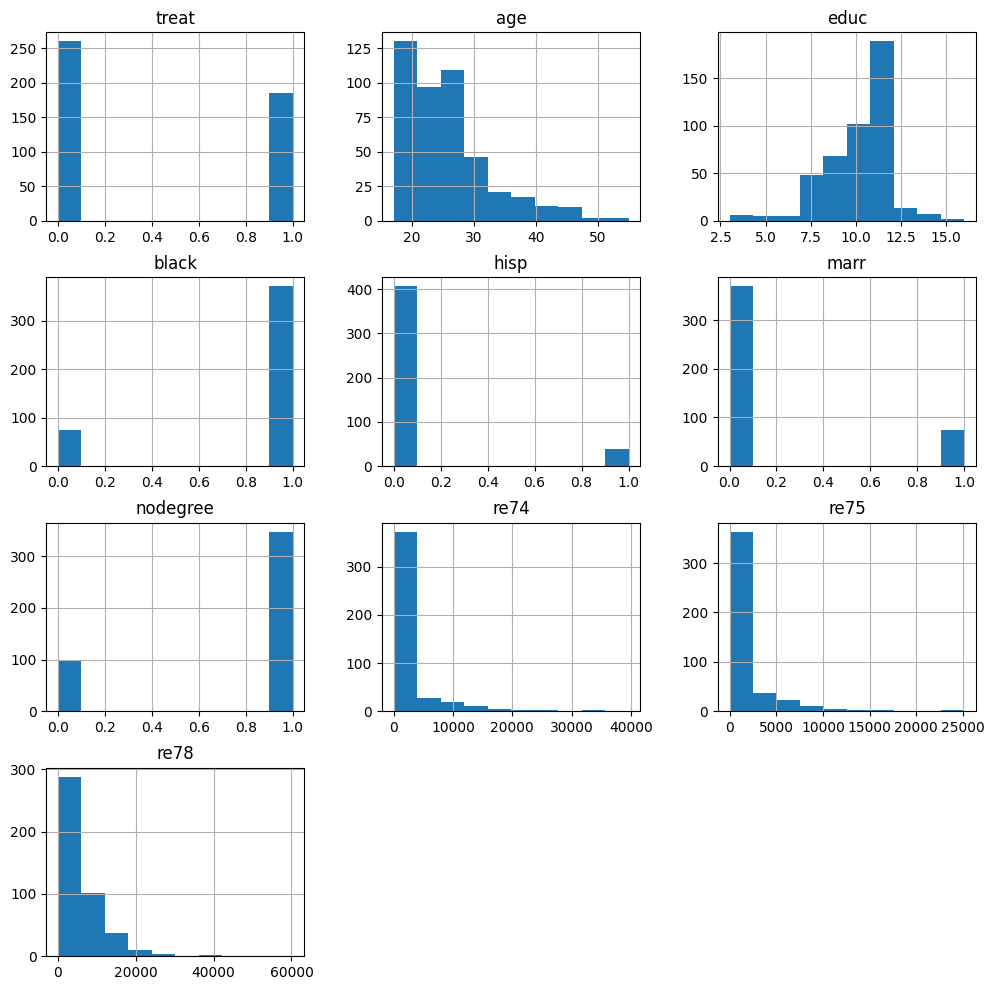

In [4]:
df.hist(figsize=(12, 12))
plt.show()

According to the histograms, treat, black, hisp, mar, nodegree are dummy variables for the treatment, being black, being of hispanic ethnicity, being married and having no degree.

The shares of people not being treated (around 260) and being treated (around 190) in the sample are more or less similar, but there is still some slight imbalance in favour of the control group. Regarding all other dummies, there are way more black people in the sample than white people, more non-hispanic people vs. hispanic people, more non-married people than married people and more people having no degree vs. having a degree.

This might be an indicator that the sample was taken from a neighborhood with a majority of black people. The sample therefore might not be representative for the whole U.S. population. This hurts the external validity of the study, but not the internal validity and will not bias the estimate for the average treatment effect of this sample.

The distribution of the years of age likely has a mean around 22 years and is a little skewed to the right. The distribution of years of education has its mean around 11 years and is a little skewed to the left.

Finally, all measures of real earnings (in the years 1974, 1975 and 1978) are extremely skewed to the right due to high outliers in each year. A solution to improve the distribution will be to use the log of real income.

To deal with these 0-zero values, I will apply a log(y+1) transformation before taking logs. This is a simple and commonly used approach, but it compresses the gap between zero and low positive earners more than the gap among higher earners. There are other methods that are specifically designed to deal with 0-values, such as the two-part model, but these would be too complex for this small sample. They may be investigated in future projects using larger samples.

However, the log(y+1) transformation is a reasonable approximation here, although the estimated treatment effects in the following notebooks should rather be treated as approximate than exact estimates.

## Correlations & Multicollinearity

Next, I will inspect the correlations between the outcome, the treatment and the features.


In [5]:
# Add logged values to the dataset

# add + 1 to handle 0-values
ly78 = np.log(df['re78'] + 1)
ly75 = np.log(df['re75'] + 1)
ly74 = np.log(df['re74'] + 1)

df['lre78'] = ly78
df['lre75'] = ly75
df['lre74'] = ly74

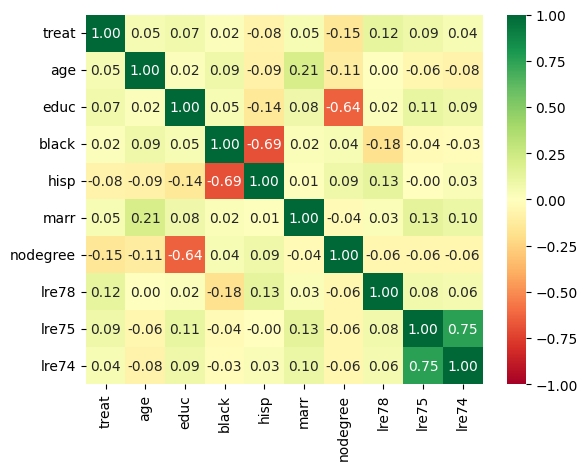

In [6]:
# Heatmap to show feature correlations
temp = df.drop(['data_id', 're74', 're75', 're78'], axis=1)

correlation_matrix = temp.corr()

sb.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', vmin=-1, vmax=1, fmt='.2f')

plt.savefig("correlations_features_outcome.png", dpi=300)
plt.show()

Overall, correlations look very good as all features only have a small correlation with the treatment variable. This might just be due to sampling variation.

As the randomization is fulfilled there are no confounding biases and internal validity of my research project is given.


Looking at the other features, some of them are moderately correlated (having no degree and years of education (-0.64), being hispanic and being black (-0.69), and real incomes from 1974 and 1975 (0.75)).

These correlations are too weak to seriously bias my estimates from the regression models, but I will still test a LASSO / Ridge model to take care of this. As the forest model mechanism works differently (as explained in a following notebook), this will not be an issue here.

The following output underlines that there is no serious issue of multicollinearity. All variance inflation factors (VIF)s, which are commonly used to inspect a case of multicollinearity, are lower than 10, which is the usual threshold.

$$
VIF=\frac{1}{1-R^2}
$$




In [7]:
# Calculate VIFs
features = ['age', 'educ', 'black', 'hisp', 'marr', 'nodegree', 'lre74', 'lre75']

X_vif = add_constant(df[features].copy())

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# Filter and print VIFs
vars = ['nodegree', 'educ', 'hisp', 'black', 'lre74', 'lre75']
for index, row in vif_data.iterrows():
    if row['feature'] in vars:
        print(f"  {row['feature']}: {row['VIF']:.2f}")


  educ: 1.74
  black: 1.99
  hisp: 2.01
  nodegree: 1.74
  lre74: 2.35
  lre75: 2.37


# Causal Discovery

Finally, before starting with the analyis, I will do causal discovery to set up a good causal structural model to base all following estimations on.
For this, I will use the Peter-Clark (PC) algorithm, which starts with a complete undirected graph and then prunes the edges based on conditional independence tests between each pair of features. Setting up a first undirected skeleton graph, where edges were already pruned, is my first step.

As my dataset is relatively small (N=445), the PC algorithm is a good choice as it can handle smaller datasets better than more complicated algorithms.

In [8]:
# Preparations

# Set colours for plots (copyright for setup code: Ryan OSullivan, https://github.com/raz1470/causal_ai/blob/main/notebooks/making%20causal%20discovery%20work%20in%20real%20world%20business%20settings.ipynb)
COLORS = [
    '#00B0F0',
    '#FF0000',
    '#B0F000'
]

def plot_graph(input_graph, node_lookup):
    '''
    Function to visualise graphs.

    Args:
        input_graph (array): Adjacency matrix representing graph
        node_lookup (dict): Dictionary containing node names.
    '''

    graph = nx.DiGraph(input_graph)

    plt.figure(figsize=(8,8))
    nx.draw(
    G=graph,
    node_color=COLORS[0],
    node_size=8000,
    arrowsize=17,
    with_labels=True,
    labels=node_lookup,
    font_color='white',
    font_size=9,
    pos=nx.circular_layout(graph)
    )



## First DAG

In [9]:
# Models with all features & pre-treatment incomes to control for pre-trends
X = df[['age', 'educ', 'black', 'hisp', 'marr', 'nodegree', 'lre75', 'lre74']]

# Relevant variables for causal discovery
data_for_dag = df[['age', 'educ', 'black', 'hisp', 'marr', 'nodegree', 'treat', 'lre78', 'lre75', 'lre74']].copy()
names_var_dag={0: 'age',
               1: 'educ',
               2: 'black',
               3: 'hisp',
               4: 'marr',
               5: 'nodegree',
                6: 'treat',
                7: 'lre78',
                8: 'lre75',
                9: 'lre74'
 }


For the applied conditional indepenced tests used for pruning edges, I chose the Fisher-z engine which works very well with continuous data and is more stable for small datasets than other engines for discrete data. It first calculates the partial correlation coefficient for two variables, conditioned on the other variables. Then, the algorithm applies a variance-stabilizing mechanism to the outcome (z-score) and tests the conditional independence.

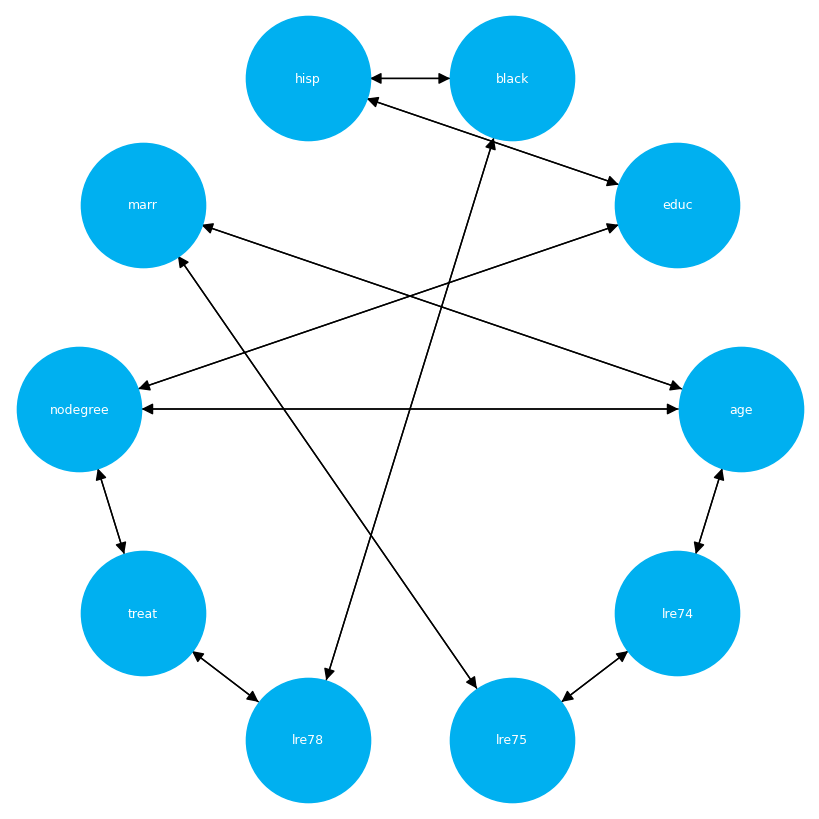

In [10]:
# Set up skeleton graph
skeleton_pred, sep_set = find_skeleton(data_for_dag.to_numpy(), 0.1, 'fisherz') # also try chi2 g2 instead of fisherz

plot_graph(input_graph=skeleton_pred, node_lookup=names_var_dag)

The next step is to determine the direction of the edges, which leads to a final directed acyclic graph (DAG). The PC-algorithm does so by orienting "V-structures" and using Christopher Meek's rules to orient remaining undirected edges and avoid creating directed cycles and new colliders.

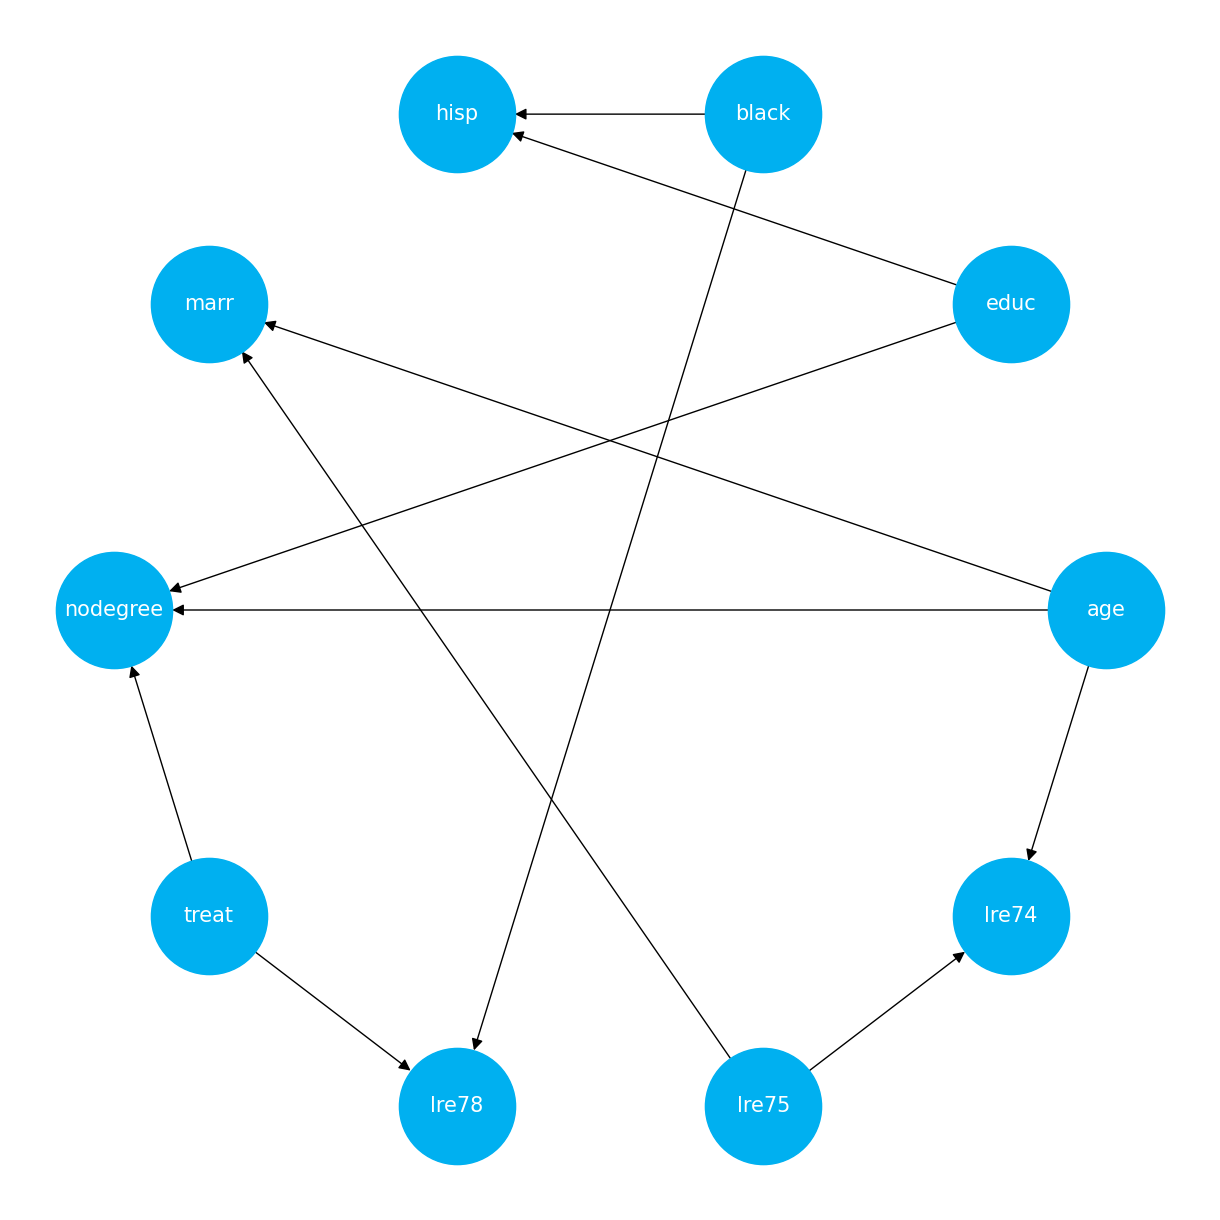

In [11]:
pc = PC(variant='stable', ci_test='fisherz', alpha=0.1)
pc.learn(data_for_dag)
graph_pred = pc.causal_matrix

graph = nx.DiGraph(graph_pred)
plt.figure(figsize=(12,12))
pos = nx.circular_layout(graph, scale=1.3)
nx.draw(
    G=graph,
    node_color=COLORS[0],
    node_size=7000,
    arrowsize=17,
    with_labels=True,
    labels=names_var_dag,
    font_color='white',
    font_size=15,
    pos=pos
)
plt.axis('off')
plt.show()

## Check for Identification

Now that a first DAG is set up, we can use it to find out whether the treatment effect of the job training participation on post-treatment earnings, lre78, can actually be identified. For this, we need to check for colliders and confounders, and need to make sure the backdoor and frontdoor criteria are fulfilled.

In [12]:
# Convert the adjacency matrix (graph_pred) into a list of edges
edges = []
num_nodes = graph_pred.shape[0]

for i in range(num_nodes):
    for j in range(num_nodes):
        if graph_pred[i, j] == 1:
            if graph_pred[j, i] == 1:
                if i < j:
                    source_node_name = names_var_dag[i]
                    target_node_name = names_var_dag[j]
                    edges.append((source_node_name, target_node_name))
            else:
                source_node_name = names_var_dag[i]
                target_node_name = names_var_dag[j]
                edges.append((source_node_name, target_node_name))

# Add all potential nodes from names_var_dag
all_node_names = list(names_var_dag.values())
bayesian_model = DiscreteBayesianNetwork()
bayesian_model.add_nodes_from(all_node_names)
# Add the derived edges
bayesian_model.add_edges_from(edges)

inference = CausalInference(bayesian_model)

I will check for potential colliders first. Potential colliders are those that have two or more parents.

In [13]:
colliders = {}
for node in bayesian_model.nodes():
    parents = bayesian_model.get_parents(node)
    if len(parents) >= 2:
        is_collider = True
        for i in range(len(parents)):
            for j in range(i + 1, len(parents)):
                parent1 = parents[i]
                parent2 = parents[j]
                if bayesian_model.has_edge(parent1, parent2) or bayesian_model.has_edge(parent2, parent1):
                    is_collider = False
                    break
            if not is_collider:
                break
        if is_collider:
            colliders[node] = parents

if colliders:
    for collider, parents in colliders.items():
        print(f" '{collider}' is a collider with parents: {parents}")
else:
  print("No colliders.")

 'hisp' is a collider with parents: ['educ', 'black']
 'marr' is a collider with parents: ['age', 'lre75']
 'nodegree' is a collider with parents: ['age', 'educ', 'treat']
 'lre78' is a collider with parents: ['black', 'treat']
 'lre74' is a collider with parents: ['age', 'lre75']


There are actually multiple colliders in the DAG. These have to be removed from the structural model as conditioning on them will introduce spurious correlations between the respective parents, the so-called collider bias.

However, the outcome lre78 is allowed to be correlated with both the treatment and pre-treatment income lre75. There is no collider bias in this case as we do not condition on lre78 on the right hand side of the equation.

Next, I will search for confounders between the treatment variable and the outcome.

In [14]:
treatment = 'treat'
outcome = 'lre78'

nx_graph = bayesian_model

confounders = []

for node in nx_graph.nodes():
    if node == treatment or node == outcome:
        continue

    # Check for ancestors of 'treat'
    is_ancestor_of_treatment = nx.has_path(nx_graph, node, treatment)

    # Check for ancestors of the outcome
    is_ancestor_of_outcome = nx.has_path(nx_graph, node, outcome)

    if is_ancestor_of_treatment and is_ancestor_of_outcome:
        confounders.append(node)

if confounders:
    print(f"Confounders for '{treatment}' and '{outcome}': {confounders}")
else:
  print("No confounders.")

No confounders.


There are no confounders between the treatment dummy and the outcome lre78, so there is no need to condition on this additional variable as the backdoor was already blocked by randomization.

This is also corroborated when looking for the backdoor adjustment set, which would give the set of features to condition on to get rid of the confounders.

In [15]:
inference.get_all_backdoor_adjustment_sets('treat', 'lre78')

`get_all_backdoor_adjustment_sets` is deprecated and will be removed in v1.3.0. Please use
            pgmpy.identification.Adjustment instead.
`is_valid_backdoor_adjustment_set` is deprecated and will be removed in v1.3.0. Please use
            pgmpy.identification.Adjustment instead.


frozenset()

Additionally, as there are other paths between the treatment and the outcome that include a mediator, the frontdoor criterion is also already fulfilled.

Finally, as there are no more colliders once excluded from the structural model, and both the backdoor and frontdoor criteria are fullfilled, the conditions for identification of the treatment effect are met.

These are:

1. Unconfoundedness

$$
[\{Y_i(0), Y_i(1)\} \perp \! \! \perp W_i] \ | \ X_i,
$$

which assumes that the outcomes (for the treatment and control group) are independent of the treatment once all covariates are controlled for. This is fulfilled by the nature of the RCT. This criterion also makes sure that prediction methods based on matching that I will apply later, are consistent for the ATE and that the CATE can be identified. All presented estimates do not suffer from additional confounding bias and are therefore consistent.


2. Overlap

of the propensity score (estimated probability of receiving treatment), which should be bounded away from 0 and 1 to ensure nice properties of the respective estimators,

$$
0 < e(x) = P(W_i =1 \ |\  X_i =x) \;\; \forall \  x.
$$

This will be accounted for later in the analyis.

3. SUTVA

(Stable Unit Treatment Value Assumption). This states that the treatment of unit 1 cannot influence the outcome of another unit 2 (no interference) and makes sure that every treated subject receives exactly the same treatment as defined (no hidden versions). As I cannot check this myself, I will assume that the experiment was well-designed and that SUTVA is met.



## Improved DAG

Now, I will plot the DAG again, but exclude the identified colliders.

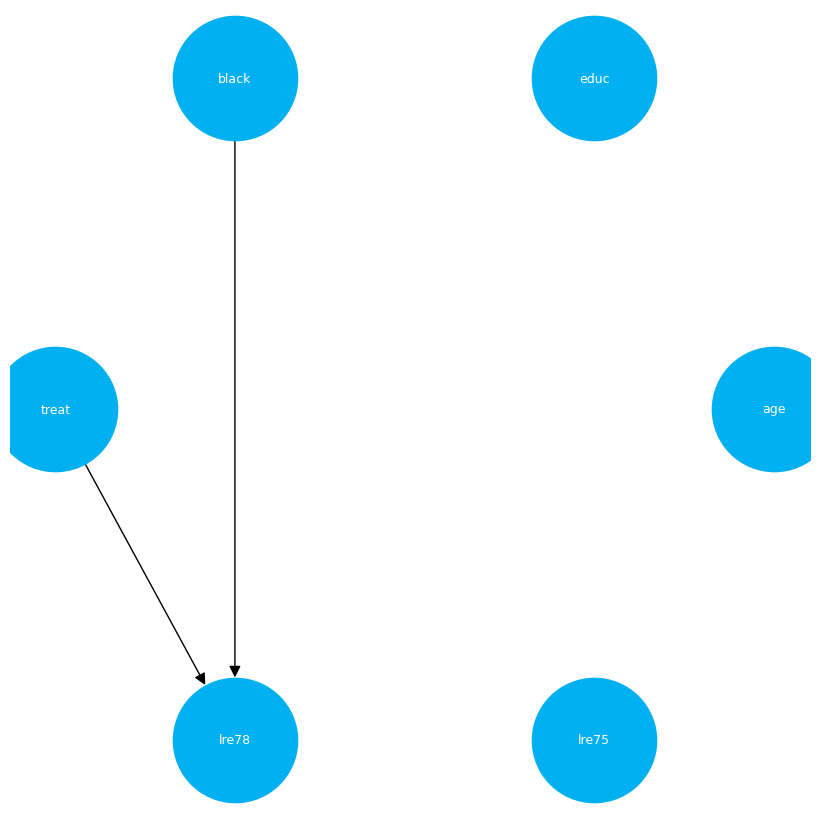

In [16]:
nodes_to_remove = ['hisp', 'nodegree', 'marr', 'lre74']

for node_to_remove in nodes_to_remove:
    index_to_remove = -1
    for index, name in list(names_var_dag.items()):
        if name == node_to_remove:
            index_to_remove = index
            break

    if index_to_remove == -1:
        print(f"Node '{node_to_remove}' not found.")
    else:
        updated_names_var_dag = {}
        current_new_index = 0

        original_indices_before_removal = sorted(names_var_dag.keys())

        new_index_mapping = {}
        for original_idx in original_indices_before_removal:
            if original_idx != index_to_remove:
                new_index_mapping[original_idx] = current_new_index
                updated_names_var_dag[current_new_index] = names_var_dag[original_idx]
                current_new_index += 1

        # New adjacency matrix
        updated_graph_pred = np.delete(graph_pred, index_to_remove, axis=0)
        updated_graph_pred = np.delete(updated_graph_pred, index_to_remove, axis=1)

        graph_pred = updated_graph_pred
        names_var_dag = updated_names_var_dag


# Plot
graph = nx.DiGraph(graph_pred)
plt.figure(figsize=(12,12))
pos = nx.circular_layout(graph, scale=0.5)
nx.draw(
    G=graph,
    node_color=COLORS[0],
    node_size=9000,
    arrowsize=17,
    with_labels=True,
    labels=names_var_dag,
    font_color='white',
    font_size=15,
    pos=pos
)
plt.axis('off')
#plt.savefig('DAG_no_colliders.png', bbox_inches='tight')
plt.show()

Only the treatment and the race have a direct impact on post-treatment earnings, but I will still keep all other variables that were not found to be colliders in the model. The DAG only uncovers direct conditional dependences, but there still might be indirect influences between those features, which are not depicted. Also, algorithms such as PC might miss weak causal links, and keeping these features will be very useful to uncover the heterogeneity in the treatment effects.